In [ ]:
import pandas as pd

df= pd.read_csv('/Users/gretawette/Documents/Thesis/03_Framing/outputs/media_framing_final_run_5_4mini_classifications.csv')

In [ ]:
from pathlib import Path

root = Path("/Users/gretawette/Documents/Thesis")

topics = pd.read_csv(
    root / "02_TopicModeling/outputs/03_new_topic_assignments.csv",
    usecols=["row_id", "source", "Manual Topic Label", "Manual Cluster Label"],
)

# Normalise source names to match the framing CSV
topics["source"] = topics["source"].replace({
    "RT":             "RT DE",
    "RT_de":          "RT DE",
    "Tichys_Einblick": "Tichys Einblick",
    "Nius":            "NIUS",
})

df = df.merge(
    topics,
    on=["row_id", "source"],
    how="left",
)

print(f"Rows: {len(df)}")
print(f"Manual Topic Label   — filled: {df['Manual Topic Label'].notna().sum()}  |  missing: {df['Manual Topic Label'].isna().sum()}")
print(f"Manual Cluster Label — filled: {df['Manual Cluster Label'].notna().sum()}  |  missing: {df['Manual Cluster Label'].isna().sum()}")
print()
print(df[["source", "row_id", "category", "Manual Topic Label", "Manual Cluster Label"]].head(10).to_string(index=False))


Rows: 11975
Manual Topic Label   — filled: 5654  |  missing: 6321
Manual Cluster Label — filled: 5654  |  missing: 6321

     source  row_id                         category            Manual Topic Label          Manual Cluster Label
Antispiegel       1                          NEUTRAL            AfD Party Politics         German Party Politics
Antispiegel       4 DISINFORMATION/FALSCHDARSTELLUNG Ukrainian Military Operations            Russia-Ukraine War
Antispiegel       5             VERSAGEN/INKOMPETENZ         Corruption Journalism Media & Information Ecosystem
Antispiegel       5                       IRRELEVANT         Corruption Journalism Media & Information Ecosystem
Antispiegel       5 DISINFORMATION/FALSCHDARSTELLUNG         Corruption Journalism Media & Information Ecosystem
Antispiegel       5          VERZERRUNG/MANIPULATION         Corruption Journalism Media & Information Ecosystem
Antispiegel       5          VERZERRUNG/MANIPULATION         Corruption Journalism Media

In [ ]:
df['source'].value_counts()

## Filter data (exclude IRRELEVANT & Tagesschau)

In [33]:
df = df[df['category'] != 'IRRELEVANT']
df = df[df['source']   != 'Tagesschau']

print(f"Rows after filtering: {len(df)}")
print(f"Sources remaining: {sorted(df['source'].unique())}")

# Rename outlets to display names
OUTLET_RENAME = {
    "RT_de":           "RT DE",
    "Tichys_Einblick": "Tichys Einblick",
    "Nius":            "NIUS",
}
df["source"] = df["source"].replace(OUTLET_RENAME)


Rows after filtering: 7339
Sources remaining: ['Antispiegel', 'Compact', 'Deutschlandkurier', 'Nius', 'RT_de', 'Tichys_Einblick']


## Topic Level Analysis

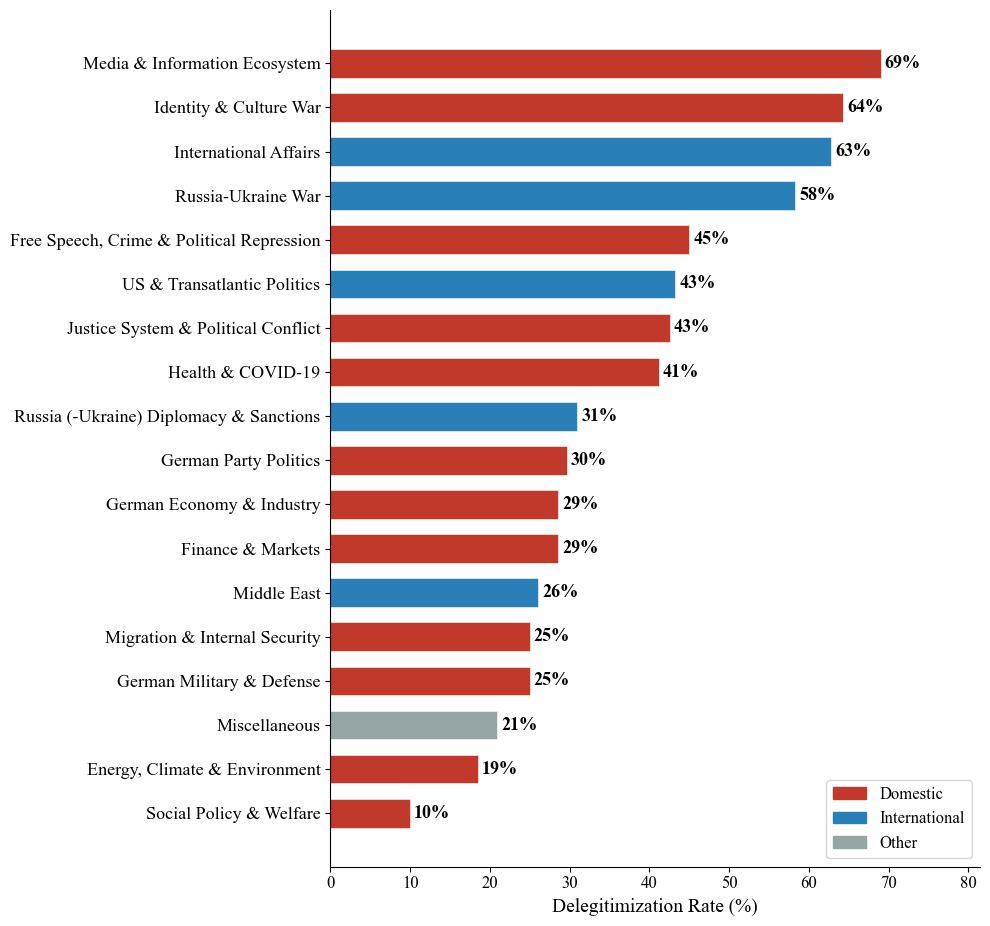

In [34]:
# ── Delegitimization rate per topic cluster, coloured by geography ───────────
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.family"] = "Times New Roman"

DOMESTIC = {
    "Social Policy & Welfare", "Health & COVID-19", "Energy, Climate & Environment",
    "German Economy & Industry", "Migration & Internal Security", "German Party Politics",
    "Free Speech, Crime & Political Repression", "Media & Information Ecosystem",
    "Justice System & Political Conflict", "Identity & Culture War",
    "Finance & Markets", "German Military & Defense",
}
INTERNATIONAL = {
    "Middle East", "Russia (-Ukraine) Diplomacy & Sanctions",
    "US & Transatlantic Politics", "Russia-Ukraine War", "International Affairs",
}
GEO_COLOR = {"Domestic": "#c0392b", "International": "#2980b9", "Other": "#95a5a6"}

def _geo(c):
    return "Domestic" if c in DOMESTIC else "International" if c in INTERNATIONAL else "Other"

df_known = df.dropna(subset=["Manual Cluster Label"]).copy()
df_known["Manual Cluster Label"] = df_known["Manual Cluster Label"].str.rstrip("#").str.strip()

total_c   = df_known.groupby("Manual Cluster Label").size()
framing_c = df_known[df_known["category"] != "NEUTRAL"].groupby("Manual Cluster Label").size()
deleg     = ((framing_c / total_c) * 100).dropna().sort_values(ascending=True)
colors    = [GEO_COLOR[_geo(c)] for c in deleg.index]

fig, ax = plt.subplots(figsize=(10, max(6, len(deleg) * 0.52)))
bars = ax.barh(deleg.index, deleg.values, color=colors, edgecolor="white", linewidth=0.4, height=0.65)

for bar, val in zip(bars, deleg.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%", va="center", fontsize=13, fontweight="bold")

ax.set_xlabel("Delegitimization Rate (%)", fontsize=14)
ax.set_xlim(0, deleg.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(False)
ax.tick_params(axis="y", labelsize=13)
ax.tick_params(axis="x", labelsize=12)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in GEO_COLOR.items()],
          loc="lower right", fontsize=12, frameon=True)
plt.tight_layout()
plt.show()


In [35]:
# ── Average delegitimisation rate: domestic vs international per outlet ───────
# Reuses df_known, _geo(), from cell above

df_known["geo"] = df_known["Manual Cluster Label"].map(_geo)

results = []
for outlet, grp in df_known[df_known["source"] != "Tagesschau"].groupby("source"):
    for geo in ("Domestic", "International"):
        sub     = grp[grp["geo"] == geo]
        total   = len(sub)
        if total == 0:
            continue
        framing = (sub["category"] != "NEUTRAL").sum()
        results.append({
            "Outlet": outlet,
            "Geography": geo,
            "Delegitimisation rate": framing / total * 100,
            "n": total,
        })

summary = (
    pd.DataFrame(results)
    .pivot(index="Outlet", columns="Geography", values="Delegitimisation rate")
    .round(1)
)
summary.columns.name = None
summary["Δ (Dom − Intl)"] = (summary["Domestic"] - summary["International"]).round(1)
summary = summary.sort_values("Domestic", ascending=False)
print(summary.to_string())


                   Domestic  International  Δ (Dom − Intl)
Outlet                                                    
Antispiegel            72.4           48.5            23.9
Compact                35.9           38.7            -2.8
Deutschlandkurier      32.6           19.6            13.0


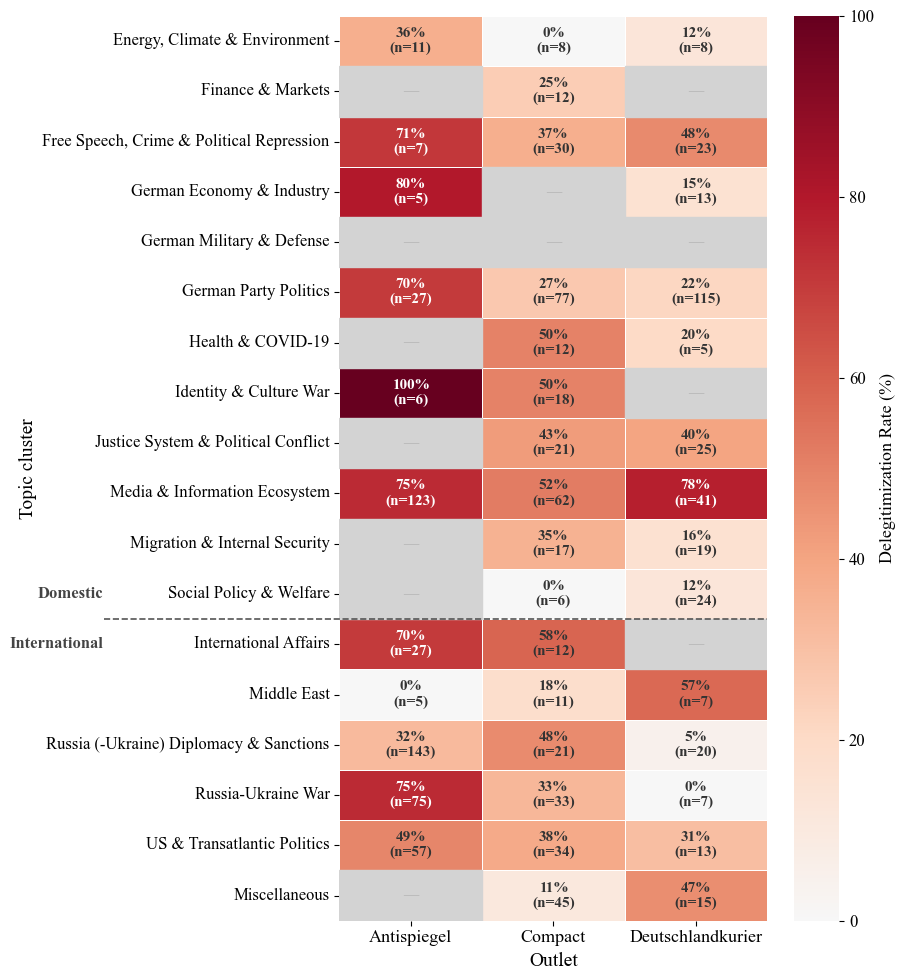

In [36]:
# ── Heatmap: delegitimization rate per topic cluster × outlet ────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import numpy as np
import matplotlib as mpl
mpl.rcParams["font.family"] = "Times New Roman"

MIN_N = 5

THESIS_SEQ = LinearSegmentedColormap.from_list(
    "thesis_seq", ["#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b", "#67001f"], N=256
)

df_known = df.dropna(subset=["Manual Cluster Label"]).copy()
df_known["Manual Cluster Label"] = df_known["Manual Cluster Label"].str.rstrip("#").str.strip()

total_g = (
    df_known.groupby(["Manual Cluster Label", "source"]).size()
    .unstack(fill_value=0).astype(float)
)
framed_g = (
    df_known[df_known["category"] != "NEUTRAL"]
    .groupby(["Manual Cluster Label", "source"]).size()
    .unstack(fill_value=0)
    .reindex_like(total_g).fillna(0)
)
rate_raw = (framed_g / total_g.replace(0, np.nan)) * 100

def _geo_rank(cluster):
    if cluster in DOMESTIC:      return 0
    if cluster in INTERNATIONAL: return 1
    return 2

sorted_clusters = sorted(rate_raw.index.tolist(), key=_geo_rank)
rate_vis  = rate_raw.reindex(sorted_clusters)
total_vis = total_g.reindex(sorted_clusters)
rate_plot = rate_vis.where(total_vis >= MIN_N)

# Rename outlet columns to display names
col_rename = {"RT_de": "RT DE", "Tichys_Einblick": "Tichys Einblick"}
rate_plot = rate_plot.rename(columns=col_rename)
total_vis = total_vis.rename(columns=col_rename)
all_outlets = rate_plot.columns.tolist()

def _add_geo_brackets(ax, clusters_ordered):
    last_dom, first_intl = None, None
    for i, c in enumerate(clusters_ordered):
        if c in DOMESTIC:      last_dom = i
        elif c in INTERNATIONAL and first_intl is None: first_intl = i
    if last_dom is None or first_intl is None: return
    sep_y = first_intl
    ax.plot([-0.55, 1.0], [sep_y, sep_y], color="#555555", linewidth=1.2,
            linestyle="--", zorder=4, transform=ax.get_yaxis_transform(), clip_on=False)
    ax.text(-0.55, sep_y - 0.35, "Domestic", ha="right", va="bottom",
            fontsize=12, color="#444444", fontweight="bold",
            transform=ax.get_yaxis_transform(), clip_on=False)
    ax.text(-0.55, sep_y + 0.35, "International", ha="right", va="top",
            fontsize=12, color="#444444", fontweight="bold",
            transform=ax.get_yaxis_transform(), clip_on=False)

fig, ax = plt.subplots(figsize=(max(10, 1.2 * len(all_outlets)),
                                max(8, 0.55 * len(sorted_clusters))))

sns.heatmap(rate_plot, ax=ax, annot=False,
            cmap=THESIS_SEQ, vmin=0, vmax=100,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Delegitimization Rate (%)"})

ax.figure.axes[-1].yaxis.label.set_size(13)
ax.figure.axes[-1].tick_params(labelsize=12)

for ri, cluster in enumerate(sorted_clusters):
    for ci, outlet in enumerate(all_outlets):
        val = rate_plot.at[cluster, outlet]
        n   = total_vis.at[cluster, outlet]
        if np.isnan(val):
            ax.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
            ax.text(ci + 0.5, ri + 0.5, "—",
                    ha="center", va="center", fontsize=11, color="#aaaaaa", zorder=3)
        else:
            ax.text(ci + 0.5, ri + 0.5, f"{val:.0f}%\n(n={int(n)})",
                    ha="center", va="center", fontsize=11, fontweight="bold",
                    color="white" if val > 60 else "#333333", zorder=3)

ax.set_xlabel("Outlet", fontsize=14)
ax.set_ylabel("Topic cluster", fontsize=14)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=12)
_add_geo_brackets(ax, sorted_clusters)
plt.tight_layout()
plt.show()


In [37]:
# CATEGORY_EN = {
#     "VERZERRUNG/MANIPULATION":            "Distortion / Manipulation",
#     "POSITIONS-/PARTEILICHKEITS-BIAS":    "Partisan Bias",
#     "DISINFORMATION/FALSCHDARSTELLUNG":   "Disinformation",
#     "VERSAGEN/INKOMPETENZ":               "Failure / Incompetence",
# }
# FRAME_ORDER = list(CATEGORY_EN.values())

# df_framed = (
#     df[df["category"].isin(CATEGORY_EN)]
#     .dropna(subset=["Manual Cluster Label"])
#     .copy()
# )
# df_framed["frame_en"] = df_framed["category"].map(CATEGORY_EN)

# # Counts: frame × cluster (raw hits)
# pivot = (
#     df_framed.groupby(["frame_en", "Manual Cluster Label"])
#     .size()
#     .unstack(fill_value=0)
#     .reindex(FRAME_ORDER)
# )

# # Normalise each row → % share of that frame's hits
# props = pivot.div(pivot.sum(axis=1), axis=0) * 100
# totals = pivot.sum(axis=1)

# # Sort clusters by total hits descending so legend order is meaningful
# cluster_order = pivot.sum(axis=0).sort_values(ascending=False).index.tolist()
# props = props[cluster_order]

# cmap = plt.get_cmap("tab20")
# cluster_colors = {c: cmap(i % 20) for i, c in enumerate(cluster_order)}

# fig, ax = plt.subplots(figsize=(12, 5))

# lefts = np.zeros(len(props))
# for cluster in cluster_order:
#     vals = props[cluster].values
#     ax.barh(props.index, vals, left=lefts,
#             color=cluster_colors[cluster], label=cluster,
#             edgecolor="white", linewidth=0.4, height=0.55)
#     lefts += vals

# # Total hit count at bar end
# for i, (frame, total) in enumerate(totals.items()):
#     ax.text(101, i, f"n={total:,}", va="center", ha="left", fontsize=8.5)

# ax.set_xlim(0, 100)
# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
# ax.set_xlabel("Share of frame hits")
# ax.set_title(
#     "Topic cluster composition per frame type\n"
#     "(share of non-neutral framing hits)",
#     fontsize=11
# )
# ax.spines[["top", "right"]].set_visible(False)
# ax.tick_params(axis="y", labelsize=9.5)
# ax.legend(
#     loc="upper left", bbox_to_anchor=(1.08, 1),
#     fontsize=7.5, frameon=True, title="Topic cluster",
#     title_fontsize=8
# )

# plt.tight_layout()
# plt.show()
